# Lab 6: Comparison of Logistic Regression and K-Nearest Neighbors (KNN) Classifiers

**Aim:** To implement Logistic Regression and KNN classifiers on the Breast Cancer Wisconsin (Diagnostic) dataset and compare their performance using standard classification evaluation metrics.

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — UCI ML Repository (`wdbc.data`)

**Name:** Reno Reji Matthew(2547145)

## 1. Import Libraries

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

pd.set_option('display.max_columns', None)

## 2. Load the Dataset

The file `wdbc.data` has no header row. As per `wdbc.names`, column 1 is the ID, column 2 is the diagnosis (M = malignant, B = benign), and columns 3-32 are 30 real-valued features (mean, standard error and worst of 10 base measurements).

In [19]:
base_features = ['radius', 'texture', 'perimeter', 'area', 'smoothness',
                 'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']
columns = ['id', 'diagnosis'] + [f'{f}_{suffix}' for suffix in ['mean', 'se', 'worst'] for f in base_features]

df = pd.read_csv('wdbc.data', header=None, names=columns)
print('Shape:', df.shape)
df.head()

Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Exploratory Data Analysis

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

diagnosis
B    357
M    212
Name: count, dtype: int64

diagnosis
B    0.6274
M    0.3726
Name: proportion, dtype: float64


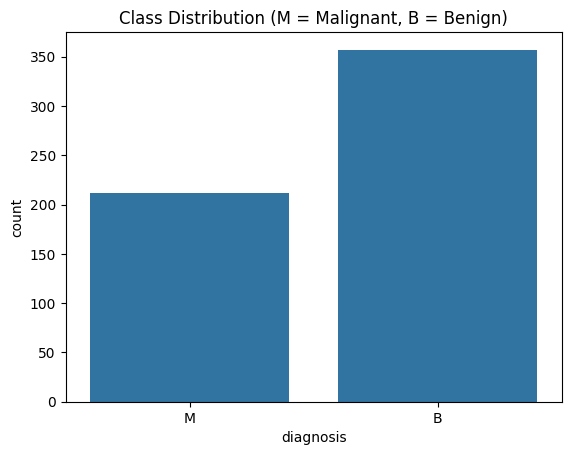

In [21]:
# Class distribution
print(df['diagnosis'].value_counts())
print()
print(df['diagnosis'].value_counts(normalize=True).round(4))

sns.countplot(x='diagnosis', data=df)
plt.title('Class Distribution (M = Malignant, B = Benign)')
plt.show()

In [22]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [23]:
# Check for missing values and duplicates
print('Total missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())

Total missing values: 0
Duplicate rows: 0


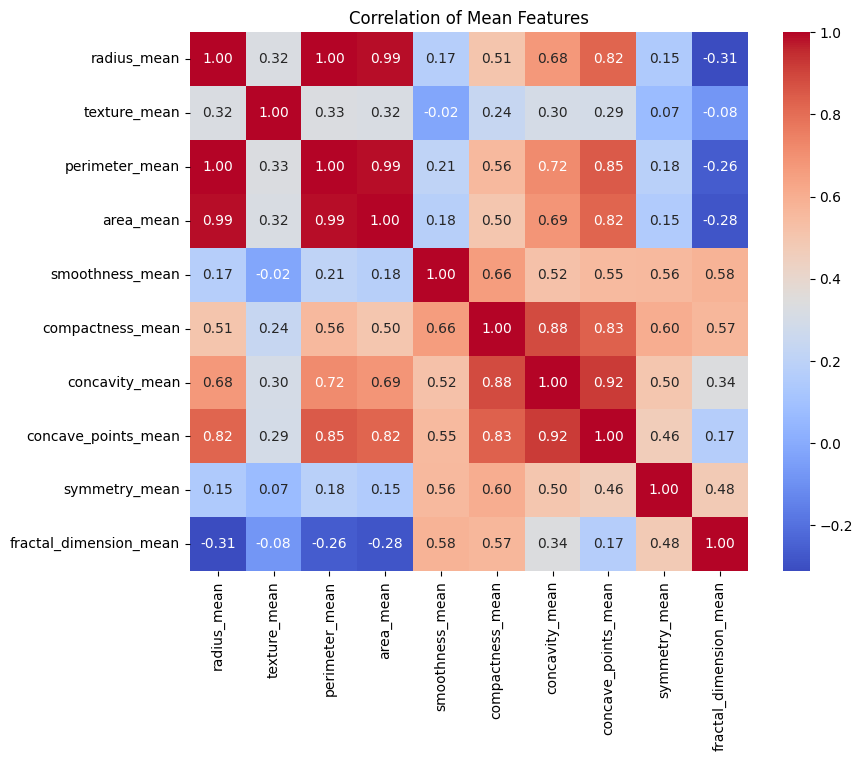

In [24]:
# Correlation heatmap of the 'mean' features
mean_cols = [f'{f}_mean' for f in base_features]
plt.figure(figsize=(9, 7))
sns.heatmap(df[mean_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation of Mean Features')
plt.show()

## 4. Data Preprocessing

- Drop the `id` column (identifier, no predictive value).
- Encode the target: M (Malignant) = 1, B (Benign) = 0.
- Standardize the features, since both Logistic Regression and KNN are sensitive to feature scale.

In [25]:
X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis'].map({'M': 1, 'B': 0})

print('Features:', X.shape)
print('Target distribution:\n', y.value_counts())

Features: (569, 30)
Target distribution:
 diagnosis
0    357
1    212
Name: count, dtype: int64


## 5. Train-Test Split

An 80:20 stratified split is used so that the class proportions are preserved in both sets.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Training set:', X_train.shape)
print('Testing set :', X_test.shape)

Training set: (455, 30)
Testing set : (114, 30)


In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Logistic Regression Classifier

In [28]:
log_reg = LogisticRegression(max_iter=5000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr, target_names=['Benign', 'Malignant']))

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



### 6.1 Model Parameters (Intercept and Coefficients)

Logistic Regression learns one coefficient per feature plus an intercept. The linear combination is $z = \beta_0 + \beta_1 x_1 + \dots + \beta_{30} x_{30}$.

In [29]:
print('Intercept:')
print(log_reg.intercept_)

print('\nCoefficients:')
print(log_reg.coef_)

Intercept:
[-0.24300533]

Coefficients:
[[ 0.36115007  0.4822194   0.35315987  0.43995028  0.35062156 -0.43954615
   0.78229835  0.95281283 -0.16399087 -0.08086512  1.23332517 -0.40761126
   0.74829471  0.90902906  0.24799098 -0.9069248  -0.09234069  0.48208908
  -0.33065773 -0.59387632  0.89696783  1.43409317  0.72311148  0.90047661
   0.42020675 -0.17348751  0.9114058   0.70399881  1.06126366  0.05486988]]


/tmp/ipykernel_8214/2427078819.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coefficient', y='feature', data=top10, palette='vlag')


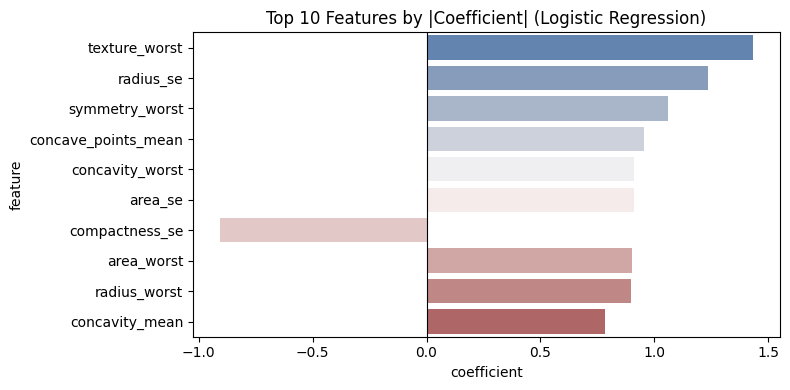

In [30]:
# Ten most influential features by absolute coefficient value
coef_df = pd.DataFrame({'feature': X.columns, 'coefficient': log_reg.coef_[0]})
coef_df['abs'] = coef_df['coefficient'].abs()
top10 = coef_df.sort_values('abs', ascending=False).head(10)

plt.figure(figsize=(8, 4))
sns.barplot(x='coefficient', y='feature', data=top10, palette='vlag')
plt.title('Top 10 Features by |Coefficient| (Logistic Regression)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### 6.2 Predicted Probabilities

Logistic Regression outputs a probability for each class. Column 0 = P(Benign), column 1 = P(Malignant).

In [31]:
probability = log_reg.predict_proba(X_test_scaled)

print('Predicted probabilities (first 5 test samples):')
print(probability[:5])
print('\nPredicted labels :', y_pred_lr[:5])
print('Actual labels    :', y_test[:5].values)

Predicted probabilities (first 5 test samples):
[[9.99635432e-01 3.64568116e-04]
 [1.07465986e-08 9.99999989e-01]
 [9.57432053e-01 4.25679471e-02]
 [4.23812678e-01 5.76187322e-01]
 [4.90844511e-01 5.09155489e-01]]

Predicted labels : [0 1 0 1 1]
Actual labels    : [0 1 0 1 0]


### 6.3 Manual Verification of the Sigmoid Computation

For a single test sample we compute $z$ by hand and pass it through the sigmoid $\sigma(z) = \dfrac{1}{1 + e^{-z}}$ to confirm it matches `predict_proba`.

In [32]:
sample = X_test_scaled[0]

z = np.dot(log_reg.coef_, sample) + log_reg.intercept_
print('z value:', z)

prob = 1 / (1 + np.exp(-z))
print('Probability (Malignant):', prob)
print('From predict_proba     :', probability[0, 1])

z value: [-7.91643251]
Probability (Malignant): [0.00036457]
From predict_proba     : 0.00036456811596278745


### 6.4 Visualizing the Sigmoid Function

The sigmoid maps the z-value to a probability between 0 and 1. The dashed lines mark the sample computed above.

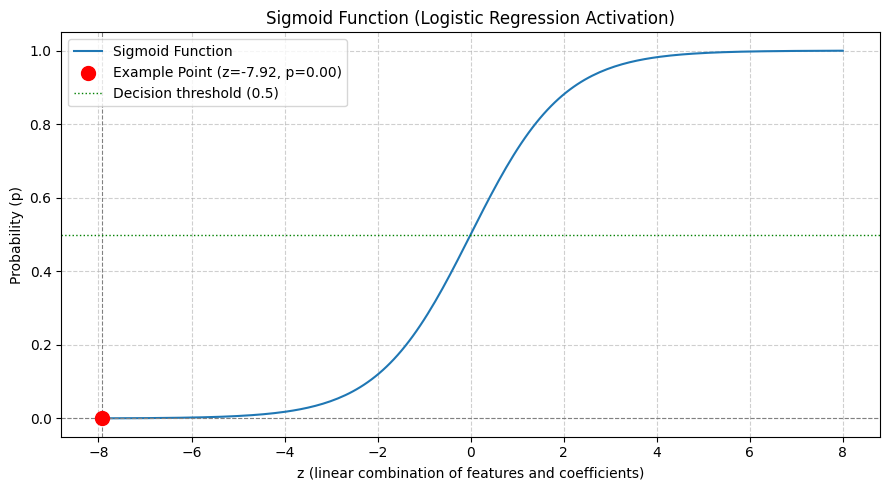

In [33]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-8, 8, 200)

plt.figure(figsize=(9, 5))
plt.plot(z_values, sigmoid(z_values), label='Sigmoid Function')
plt.scatter(z, prob, color='red', s=100, zorder=5,
            label=f'Example Point (z={z[0]:.2f}, p={prob[0]:.2f})')
plt.axvline(x=z[0], color='gray', linestyle='--', linewidth=0.8)
plt.axhline(y=prob[0], color='gray', linestyle='--', linewidth=0.8)
plt.axhline(y=0.5, color='green', linestyle=':', linewidth=1, label='Decision threshold (0.5)')
plt.title('Sigmoid Function (Logistic Regression Activation)')
plt.xlabel('z (linear combination of features and coefficients)')
plt.ylabel('Probability (p)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## 7. K-Nearest Neighbors (KNN) Classifier

The value of *k* is chosen by comparing test accuracy over a range of values.

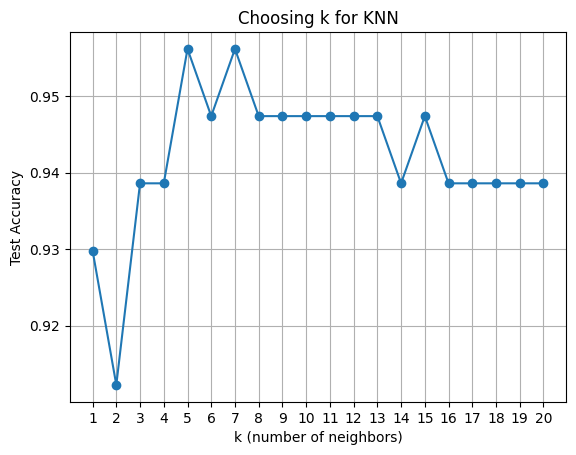

Best k = 5 with accuracy = 0.9561


In [34]:
k_range = range(1, 21)
accuracies = []
for k in k_range:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train_scaled, y_train)
    accuracies.append(accuracy_score(y_test, knn_tmp.predict(X_test_scaled)))

plt.plot(k_range, accuracies, marker='o')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Test Accuracy')
plt.title('Choosing k for KNN')
plt.xticks(k_range)
plt.grid(True)
plt.show()

best_k = k_range[int(np.argmax(accuracies))]
print('Best k =', best_k, 'with accuracy =', round(max(accuracies), 4))

In [35]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
print(classification_report(y_test, y_pred_knn, target_names=['Benign', 'Malignant']))

              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## 8. Evaluation

### 8.1 Confusion Matrices

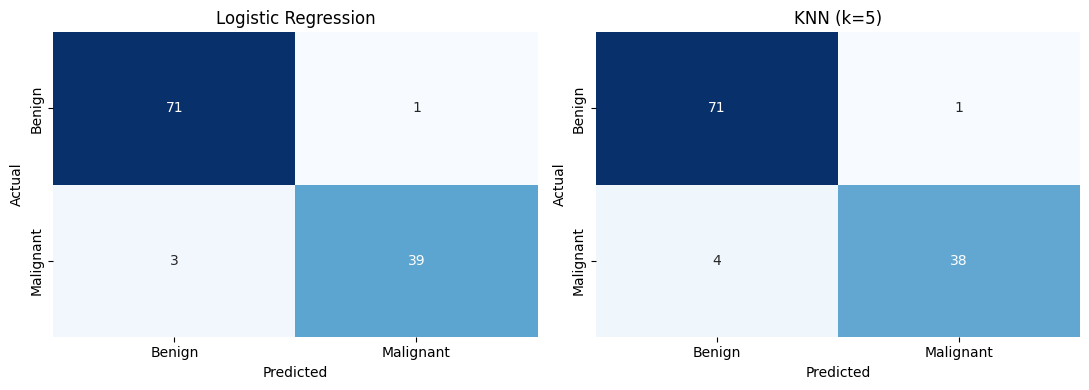

Logistic Regression:
 [[71  1]
 [ 3 39]]

KNN:
 [[71  1]
 [ 4 38]]


In [36]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm, title in zip(axes, [cm_lr, cm_knn], ['Logistic Regression', f'KNN (k={best_k})']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

print('Logistic Regression:\n', cm_lr)
print('\nKNN:\n', cm_knn)

### 8.2 Comparison Table

In [37]:
def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
    }

comparison = pd.DataFrame({
    'Logistic Regression': get_metrics(y_test, y_pred_lr),
    f'KNN (k={best_k})': get_metrics(y_test, y_pred_knn),
}).T.round(4)

comparison

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.9649,0.9750,0.9286,0.9512
KNN (k=5),0.9561,0.9744,0.9048,0.9383


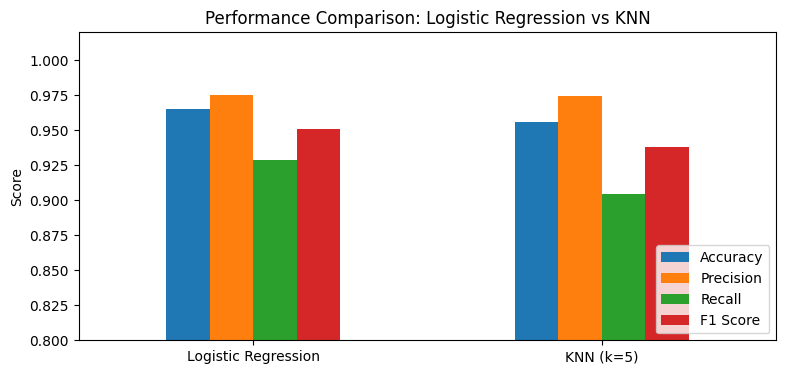

In [38]:
comparison.plot(kind='bar', figsize=(9, 4), ylim=(0.8, 1.02), rot=0)
plt.title('Performance Comparison: Logistic Regression vs KNN')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.show()

## 9. Logistic Regression Implemented from Scratch (Gradient Descent)

To understand what Scikit-Learn does internally, the same classifier is implemented manually:

1. Initialize weights and bias to zero
2. Compute the linear combination $z = Xw + b$
3. Apply the sigmoid activation to get probabilities
4. Compute the Binary Cross-Entropy (log) loss
5. Compute gradients of the loss w.r.t. $w$ and $b$
6. Update the parameters in the opposite direction of the gradients
7. Repeat until convergence, then threshold at 0.5 to get labels

In [39]:
class BreastCancerLogisticRegression:
    def __init__(self, learning_rate=0.1, epochs=1000, tolerance=1e-6):
        self.lr = learning_rate
        self.epochs = epochs
        self.tolerance = tolerance
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        # Step 3: Sigmoid activation - maps any z to the (0, 1) probability scale
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))  # clip to prevent numeric overflow

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Step 1: Parameter initialization
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        # Step 6: Iterative optimization loop
        for epoch in range(self.epochs):
            # Step 2: Linear combination (z = Xw + b)
            z = np.dot(X, self.weights) + self.bias

            # Step 3: Activation
            y_pred = self._sigmoid(z)

            # Step 4: Binary Cross-Entropy loss
            eps = 1e-15
            y_pred_clipped = np.clip(y_pred, eps, 1 - eps)
            loss = -(1 / n_samples) * np.sum(y * np.log(y_pred_clipped) + (1 - y) * np.log(1 - y_pred_clipped))
            self.loss_history.append(loss)

            # Step 5: Gradient descent update
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Stop early if the loss reduction becomes negligible
            if epoch > 0 and abs(self.loss_history[-2] - self.loss_history[-1]) < self.tolerance:
                print(f"-> Model converged early at epoch {epoch}!")
                break

    def predict_prob(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        # Step 7: Decision boundary - 1 (Malignant) if probability >= 0.5, else 0 (Benign)
        return np.where(self.predict_prob(X) >= threshold, 1, 0)

In [40]:
custom_model = BreastCancerLogisticRegression(learning_rate=0.01, epochs=10000, tolerance=1e-7)
custom_model.fit(X_train_scaled, y_train.values)

y_pred_custom = custom_model.predict(X_test_scaled)
print('Accuracy (from scratch):', round(accuracy_score(y_test, y_pred_custom), 4))
print('Accuracy (Scikit-Learn):', round(accuracy_score(y_test, y_pred_lr), 4))
print()
print(classification_report(y_test, y_pred_custom, target_names=['Benign', 'Malignant']))

Accuracy (from scratch): 0.9825
Accuracy (Scikit-Learn): 0.9649

              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



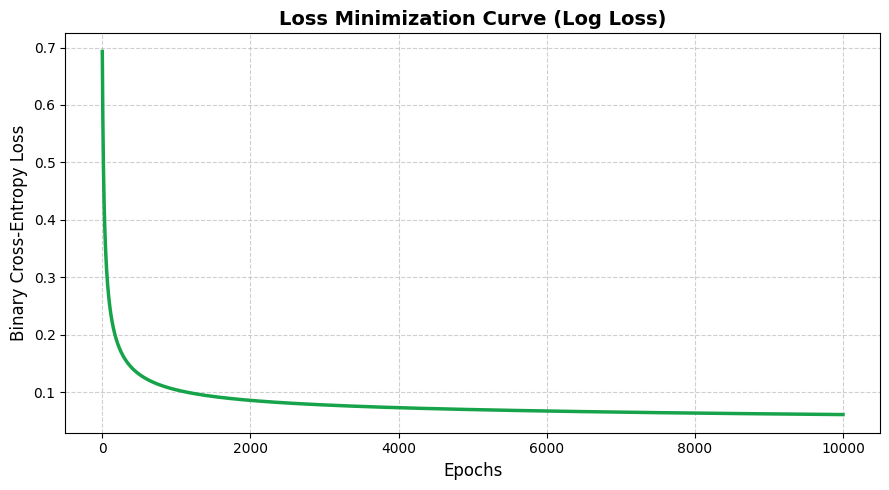

Initial loss: 0.6931
Final loss  : 0.0608
Epochs run  : 10000


In [41]:
plt.figure(figsize=(9, 5))
plt.plot(custom_model.loss_history, color='#16a34a', linewidth=2.5)
plt.title('Loss Minimization Curve (Log Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print('Initial loss:', round(custom_model.loss_history[0], 4))
print('Final loss  :', round(custom_model.loss_history[-1], 4))
print('Epochs run  :', len(custom_model.loss_history))

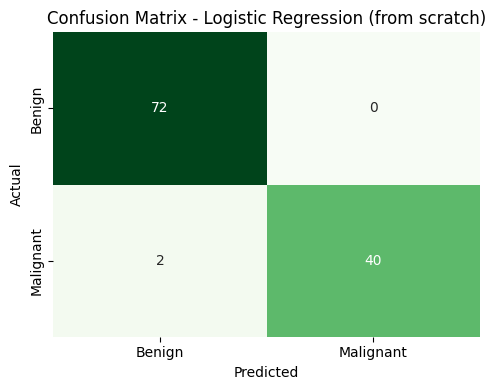

In [42]:
# Confusion matrix of the from-scratch model
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_custom), annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix - Logistic Regression (from scratch)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [43]:
# Three-way comparison including the manual implementation
full_comparison = pd.DataFrame({
    'Logistic Regression (sklearn)': get_metrics(y_test, y_pred_lr),
    'Logistic Regression (scratch)': get_metrics(y_test, y_pred_custom),
    f'KNN (k={best_k})': get_metrics(y_test, y_pred_knn),
}).T.round(4)

full_comparison

,Accuracy,Precision,Recall,F1 Score
Logistic Regression (sklearn),0.9649,0.9750,0.9286,0.9512
Logistic Regression (scratch),0.9825,1.0000,0.9524,0.9756
KNN (k=5),0.9561,0.9744,0.9048,0.9383


## 10. Result and Interpretation

In [44]:
for metric in comparison.columns:
    lr_val, knn_val = comparison.loc['Logistic Regression', metric], comparison.loc[f'KNN (k={best_k})', metric]
    winner = 'Logistic Regression' if lr_val > knn_val else ('KNN' if knn_val > lr_val else 'Tie')
    print(f'{metric:10s}: LR = {lr_val:.4f} | KNN = {knn_val:.4f} -> {winner}')

Accuracy  : LR = 0.9649 | KNN = 0.9561 -> Logistic Regression
Precision : LR = 0.9750 | KNN = 0.9744 -> Logistic Regression
Recall    : LR = 0.9286 | KNN = 0.9048 -> Logistic Regression
F1 Score  : LR = 0.9512 | KNN = 0.9383 -> Logistic Regression


### Interpretation

Logestic Performed slightly better than KNN , because Logestic's is more sutable classifier for this particular dataset because it is better in superior classification metrics and logestic is best for these perdictions.